# Load a trained AB-UPT / DrivAerML run in Python

This notebook shows the **interactive** counterpart to `noether-eval`: load a trained AB-UPT model and its dataset directly into Python, run a forward pass on a single sample, and inspect the predictions.

Use this when you want to:
- inspect what the model actually produces on individual samples,
- prototype a new visualization,
- apply a trained model to **your own data** (a CAD mesh, a custom point cloud — see section 6),
- compare predictions against ground truth without going through the trainer.

For reproducible eval (metrics, callbacks, logs, VTK export), use `noether-eval` or `python -m showcase.cli evaluate` instead.

**Requires `matplotlib`** for section 5's plots — install with `uv pip install matplotlib` if your environment doesn't have it.

<div class="alert alert-block alert-warning">
The numbers and plots shown here come from an AB-UPT model trained for only 2 epochs on DrivAerML - illustrative of the inference flow, not of the model's true accuracy.

We are not aiming here for high quality results, but to show the concepts of how to initialize and run inference in an interactive manner.

_Tested against `emmiai-noether` 2026.4.0._
</div>

## Configure paths

Edit the two paths. `RUN_DIR` is the training run output directory (it contains `hp_resolved.yaml` and a `checkpoints/` subdirectory). `DATASET_ROOT` is where the DrivAerML data lives on **this** machine; if you don't already have it, the subsampled 10× copy used here is published at [huggingface.co/datasets/EmmiAI/DrivAerML_subsampled_10x](https://huggingface.co/datasets/EmmiAI/DrivAerML_subsampled_10x).

In [21]:
import sys
from pathlib import Path

import torch
from torch.utils.data import DataLoader

# The loaded run config refers to recipe classes by dotted path (e.g. ``aero_cfd.datasets.drivaerml.DrivAerMLDataset``); ConfigSchema validation imports them,
# so the recipe's src must be importable. Walk up from cwd so this works whether Jupyter was launched from the repo root or from ``notebooks/``.
_p = Path.cwd().resolve()
while _p != _p.parent and not (_p / "recipes" / "aero_cfd" / "src").exists():
    _p = _p.parent
_aero_src = _p / "recipes" / "aero_cfd" / "src"
if _aero_src.exists() and str(_aero_src) not in sys.path:
    sys.path.insert(0, str(_aero_src))

from noether.inference import Run  # noqa: E402

RUN_DIR = Path("/path/to/outputs/<run_id>")  # contains hp_resolved.yaml + checkpoints/
DATASET_ROOT = Path("/path/to/drivaerml")  # local copy of the dataset (only for sections 2–5)

SPLIT = "test"
CHECKPOINT = "latest"  # adjust to match your run; common tags: "last", "latest", "best_model.loss.test.total", "E10"
SAMPLE_ID = "run_1"  # subdirectory under DATASET_ROOT to use for section 1's raw-tensor flow
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# AB-UPT / DrivAerML sampling counts used by section 1. These must match the training pipeline; look them up in
# ``hp_resolved.yaml`` under ``datasets.<split>.pipeline.*`` (or ``run.config.datasets[SPLIT].pipeline`` once a Run
# is constructed in section 2). Changing these here without retraining means the model sees a different input
# distribution than it was trained on.
N_GEOM, N_SUPER, N_SURF_ANCHOR, N_VOL_ANCHOR = 16384, 4096, 2048, 4096

## Setup: visualization helper

Sections 1 and 6 both produce the same 3-panel figure (GT, prediction, signed error) plus a Δ-distribution histogram on the right. Defining the plot once means the two sections differ only in **how they got the tensors**, not in how they render them.

In [22]:
import matplotlib.pyplot as plt


def plot_prediction(positions, gt, pred, *, field, save_path=None):
    """3-panel 3D scatter (GT, prediction, signed error) + Δ-distribution histogram.

    GT and prediction share a colormap range so the visual comparison is fair; the signed-error panel gets a
    symmetric diverging scale centered at 0. The horizontal histogram on the right reuses the diff y-axis so bars
    line up with the colorbar — a tall narrow band means the error is concentrated; a wide spread means it covers
    the full range. Pass ``save_path`` to write the figure to disk; otherwise it's shown inline.
    """
    diff = pred - gt
    shared_vmin = min(gt.min().item(), pred.min().item())
    shared_vmax = max(gt.max().item(), pred.max().item())
    diff_vmax = diff.abs().max().item()

    panels = [
        ("ground truth", gt, {"vmin": shared_vmin, "vmax": shared_vmax}),
        ("prediction", pred, {"vmin": shared_vmin, "vmax": shared_vmax}),
        ("signed error (pred − GT)", diff, {"cmap": "coolwarm", "vmin": -diff_vmax, "vmax": diff_vmax}),
    ]
    fig = plt.figure(figsize=(20, 5))
    gs = fig.add_gridspec(1, 4, width_ratios=[3, 3, 3, 1.2])
    for i, (title, values, kwargs) in enumerate(panels):
        ax = fig.add_subplot(gs[0, i], projection="3d")
        sc = ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], c=values.squeeze(-1), s=1, **kwargs)
        ax.set_title(f"{field} — {title}")
        fig.colorbar(sc, ax=ax, shrink=0.5)
    ax_hist = fig.add_subplot(gs[0, 3])
    ax_hist.hist(diff.squeeze(-1).numpy(), bins=60, orientation="horizontal", color="0.4")
    ax_hist.axhline(0, color="k", linewidth=0.6, linestyle="--")
    ax_hist.set_ylim(-diff_vmax, diff_vmax)
    ax_hist.set_xlabel("count")
    ax_hist.set_ylabel(f"{field} (pred − GT)")
    ax_hist.set_title("Δ distribution")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
        print(f"saved {save_path}")
        plt.close(fig)
    else:
        plt.show()

## 1. Load and run inference from just a checkpoint file

The lightest entry point. `Run.from_checkpoint(path)` reads embedded metadata (model config, kind, normalizer specs, dataset statistics) directly out of the `.th` file — no run directory, no `hp_resolved.yaml`, no recipe stats file required. The `Run` that comes back is **checkpoint-only**: `.model()` and `.normalizers()` work, but accessing `.config` or calling `.dataset()` will raise with a useful message.

Below we load model + normalizers, read raw `.pt` arrays for a single DrivAerML sample, sample geometry/anchor points (the same way the training pipeline does), normalize, run a forward pass, denormalize predictions back to physical units, and plot ground truth vs. prediction. This is the complete inference flow with **no dependency on noether's Dataset/Pipeline machinery** — swap the `.pt` paths for any tensors you can construct (a CAD mesh, a CFD-solver dump, a custom point cloud) and the rest is unchanged.

What you give up vs. opening the full run directory: the dataset class (for iterating samples), the pipeline-collated batch format the trainer used, and access to `run.config`. Sections 2+ pick up there.

In [23]:
ckpt_path = RUN_DIR / "checkpoints" / f"ab_upt_cp={CHECKPOINT}_model.th"
ckpt_run = Run.from_checkpoint(ckpt_path)
model_only = ckpt_run.model(device=DEVICE)
norms_only = ckpt_run.normalizers()

print(f"class:       {type(model_only).__name__}")
print(f"params:      {sum(p.numel() for p in model_only.parameters()):,}")
print(f"eval mode:   {not model_only.training}")
print(f"normalizers: {sorted(norms_only.keys())}")

class:       AeroABUPT
params:      35,051,147
eval mode:   True
normalizers: ['surface_friction', 'surface_position', 'surface_pressure', 'volume_position', 'volume_pressure', 'volume_velocity', 'volume_vorticity']


In [24]:
# 1. Read raw arrays straight from disk. DrivAerML ships one .pt per field per
#    sample (see `noether.data.datasets.cfd.caeml.filemap.CAEML_FILEMAP`).
sample_dir = DATASET_ROOT / SAMPLE_ID
raw_surface_pos = torch.load(sample_dir / "surface_position_vtp.pt", weights_only=True)  # (N_surf, 3)
raw_volume_pos = torch.load(sample_dir / "volume_cell_position.pt", weights_only=True)  # (N_vol, 3)
raw_surface_pressure = torch.load(sample_dir / "surface_pressure.pt", weights_only=True)  # (N_surf,) — for MAE only
print(f"raw shapes: surface={tuple(raw_surface_pos.shape)}, volume={tuple(raw_volume_pos.shape)}")

# 2. Sample positions (same torch.randperm-based logic the training pipeline uses).
#    Note: this uses an independent seed, so the anchor points sampled here will NOT match
#    those drawn by the Dataset+Pipeline path in sections 4–6. The two visualizations are
#    qualitatively comparable, not point-for-point.
gen = torch.Generator().manual_seed(0)
geom_idx = torch.randperm(raw_surface_pos.shape[0], generator=gen)[:N_GEOM]
geom_pos = raw_surface_pos[geom_idx]  # (N_geom, 3)
supernode_idx = torch.randperm(N_GEOM, generator=gen)[:N_SUPER]  # (N_super,)
surf_anchor_idx = torch.randperm(raw_surface_pos.shape[0], generator=gen)[:N_SURF_ANCHOR]
vol_anchor_idx = torch.randperm(raw_volume_pos.shape[0], generator=gen)[:N_VOL_ANCHOR]
surf_anchor_pos = raw_surface_pos[surf_anchor_idx]  # (N_surf_anchor, 3)
vol_anchor_pos = raw_volume_pos[vol_anchor_idx]  # (N_vol_anchor, 3)

# 3. Normalize each position with its matching field normalizer and assemble the
#    forward-input dict. Single-sample batch → batch_idx is all zeros.
inputs_only = {
    "geometry_position": norms_only["surface_position"](geom_pos).to(DEVICE),
    "geometry_supernode_idx": supernode_idx.to(DEVICE),
    "geometry_batch_idx": torch.zeros(N_GEOM, dtype=torch.long, device=DEVICE),
    "surface_anchor_position": norms_only["surface_position"](surf_anchor_pos).unsqueeze(0).to(DEVICE),
    "volume_anchor_position": norms_only["volume_position"](vol_anchor_pos).unsqueeze(0).to(DEVICE),
}

with torch.inference_mode():
    pred_only = model_only(**inputs_only)

# 4. Denormalize the prediction and compare against raw GT at the same anchor
#    indices. MAE is in physical units (Pa for surface_pressure).
pred_pressure_only = norms_only["surface_pressure"].inverse(
    pred_only["surface_pressure"][0].cpu()
)  # (N_surf_anchor, 1)
gt_pressure_only = raw_surface_pressure[surf_anchor_idx].unsqueeze(-1)  # (N_surf_anchor, 1)
mae_only = (pred_pressure_only - gt_pressure_only).abs().mean().item()
print(
    f"\npredicted surface_pressure: shape={tuple(pred_pressure_only.shape)}, "
    f"min={pred_pressure_only.min().item():.3f}, max={pred_pressure_only.max().item():.3f}"
)
print(f"MAE vs raw GT at the sampled anchor points: {mae_only:.3f}")

raw shapes: surface=(882809, 3), volume=(14744958, 3)

predicted surface_pressure: shape=(2048, 1), min=-1378.925, max=711.709
MAE vs raw GT at the sampled anchor points: 94.497


### Visualize the prediction

Same 3-panel layout (GT, prediction, signed delta) plus Δ-distribution histogram as the dataset-driven flow in section 6 — here built entirely from the checkpoint + raw `.pt` files. With a well-trained model the prediction should be qualitatively similar to GT, and the Δ histogram should sit in a tight band around 0.

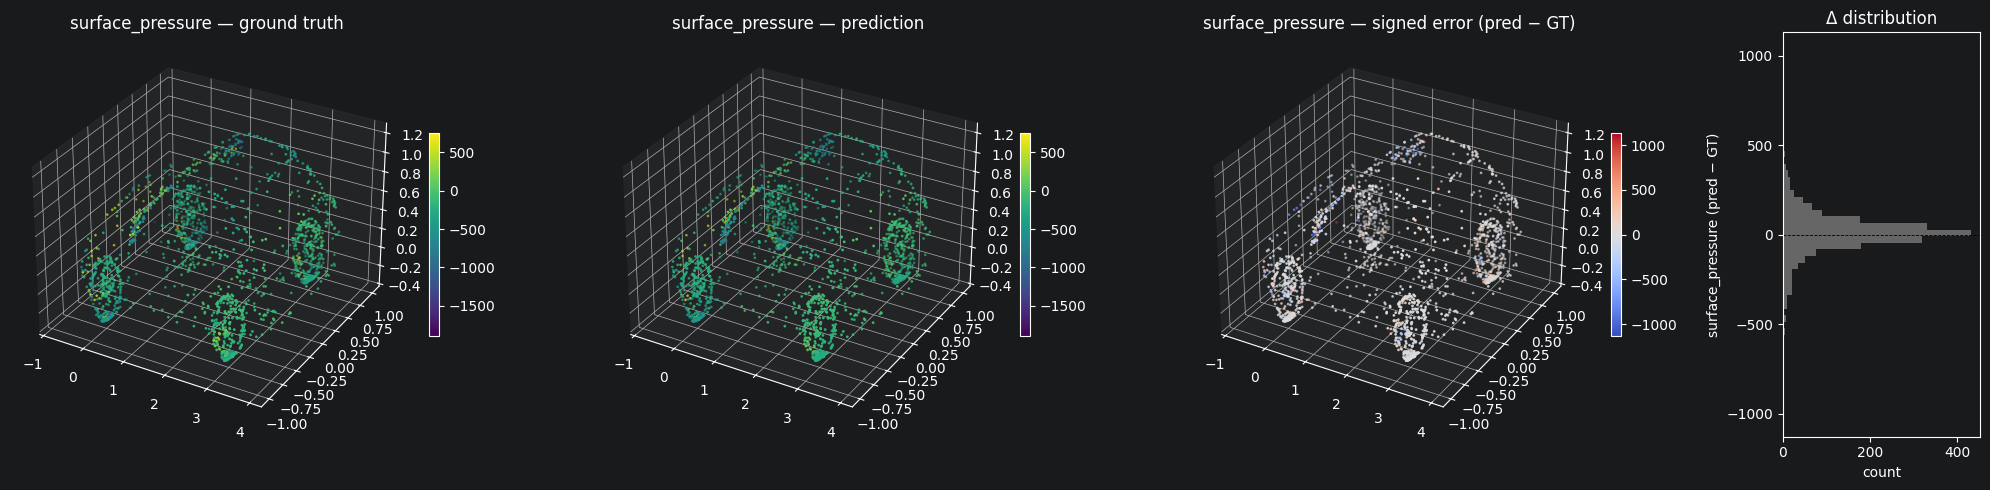

In [25]:
plot_prediction(
    positions=surf_anchor_pos,
    gt=gt_pressure_only,
    pred=pred_pressure_only,
    field="surface_pressure",
)

## 2. Open the run for the full Dataset/Pipeline flow

Section 1 ran end-to-end inference without ever touching `Run`. So why use `Run` at all? When you have the run output directory, `Run` adds:

- the **same `Dataset` class** the trainer used — `run.dataset()` returns it wired up with the pipeline collator, ready to feed a `DataLoader` for batched / multi-sample iteration;
- access to the full **hyperparameter config** via `run.config`, including anything not embedded in the checkpoint;
- a single handle to manage all of the above without re-loading anything.

Below we open the run, patch the dataset root for this machine, and explore. The model and normalizers we get from `Run` are functionally identical to section 1's — sections 3+ show the dataset-driven path side-by-side with what you've already seen.

In [26]:
run = Run(RUN_DIR)

# Point each split's dataset at the local data root.
for ds_cfg in run.config.datasets.values():
    ds_cfg.root = str(DATASET_ROOT)

print(f"run dir:    {RUN_DIR.name}")
print(f"model.name: {run.config.model.name}")
print(f"splits:     {list(run.config.datasets)}")

run dir:    2026-05-13_si82k
model.name: ab_upt
splits:     ['train', 'val', 'test']


## 3. Build the dataset, the model, and the normalizers

`run.dataset(split)` instantiates the dataset and wires its collator the same way the trainer does, ready to feed into a `DataLoader`. `run.model(...)` and `run.normalizers(split)` are functionally identical to section 1's `load_model_from_checkpoint` and `load_normalizers_from_checkpoint` — different loading paths, same outputs. The cell below builds all three and verifies the model equivalence explicitly.

**Note:** only `run.dataset()` needs the original data files.

In [27]:
dataset = run.dataset(SPLIT)
model = run.model(checkpoint=CHECKPOINT, device=DEVICE)
norms = run.normalizers(SPLIT)

print(f"{len(dataset)=}")
print(f"model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"normalizers: {sorted(norms.keys())}")

# Equivalence check: same weights → same model.
matches = all(torch.equal(a, b) for a, b in zip(model_only.parameters(), model.parameters(), strict=True))
print(f"matches section 1's model from checkpoint: {matches}")

len(dataset)=50
model parameters: 35,051,147
normalizers: ['surface_friction', 'surface_position', 'surface_pressure', 'volume_position', 'volume_pressure', 'volume_velocity', 'volume_vorticity']
matches section 1's model from checkpoint: True


## 4. Inspect one sample

Each item the dataset returns is a dict of tensors, already normalized by the pipeline. For AB-UPT on DrivAerML, the relevant keys are geometry positions, surface/volume anchor positions, and the corresponding target fields (surface pressure, volume velocity, etc.).

In [28]:
sample = dataset[0]
for k, v in sample.items():
    shape = tuple(v.shape) if hasattr(v, "shape") else type(v).__name__
    print(f"{k:40s}  {shape}")

volume_velocity                           (13414253, 3)
surface_friction                          (779271, 3)
index                                     int
volume_position                           (13414253, 3)
volume_vorticity                          (13414253, 3)
surface_position                          (779271, 3)
volume_pressure                           (13414253, 1)
surface_pressure                          (779271, 1)


## 5. Forward pass through the model

Use a `DataLoader` of batch size 1 with the dataset's own collator — that handles all the batch-idx bookkeeping AB-UPT expects. The forward kwargs below are the AB-UPT-on-DrivAerML inputs (see `AeroCFDPreset.forward_properties_map` in `recipes/aero_cfd/src/aero_cfd/presets/base.py`).

In [29]:
# Prefer the forward-key list embedded in the run config (set by the preset that built this model);
# fall back to the AB-UPT defaults if the field is missing for any reason.
AB_UPT_FORWARD_KEYS = list(run.config.model.forward_properties or []) or [
    "geometry_position",
    "geometry_supernode_idx",
    "geometry_batch_idx",
    "surface_anchor_position",
    "volume_anchor_position",
]

loader = DataLoader(dataset, batch_size=1, collate_fn=dataset.pipeline)
batch = next(iter(loader))

missing = [k for k in AB_UPT_FORWARD_KEYS if k not in batch]
if missing:
    raise KeyError(f"batch missing expected forward keys: {missing}. Got: {sorted(batch)}")

inputs = {k: batch[k].to(DEVICE) for k in AB_UPT_FORWARD_KEYS}
with torch.inference_mode():
    pred = model(**inputs)

print("forward keys:", AB_UPT_FORWARD_KEYS)
print("batch keys:  ", sorted(batch))
print({k: tuple(v.shape) for k, v in pred.items()})

forward keys: ['geometry_position', 'geometry_supernode_idx', 'geometry_batch_idx', 'surface_anchor_position', 'volume_anchor_position']
batch keys:   ['geometry_batch_idx', 'geometry_position', 'geometry_supernode_idx', 'index', 'surface_anchor_position', 'surface_friction_target', 'surface_pressure_target', 'volume_anchor_position', 'volume_pressure_target', 'volume_velocity_target', 'volume_vorticity_target']
{'surface_pressure': (1, 2048, 1), 'surface_friction': (1, 2048, 3), 'volume_pressure': (1, 4096, 1), 'volume_velocity': (1, 4096, 3), 'volume_vorticity': (1, 4096, 3)}


## 6. Denormalize and visualize

Predictions come out in normalized units. Use the normalizers from section 3 — `norms[field].inverse(tensor)` is the inverse transform — to bring them back into physical space. AB-UPT predictions on DrivAerML are shaped `(B, N, C)` per field; with `batch_size=1` we take `[0]` to get a single sample.

Below we plot ground-truth vs predicted surface pressure as a 3D scatter. For ParaView-ready VTP files use `recipes/aero_cfd/showcase/utils/vtk_export.py:export_pointcloud_to_vtk` instead.

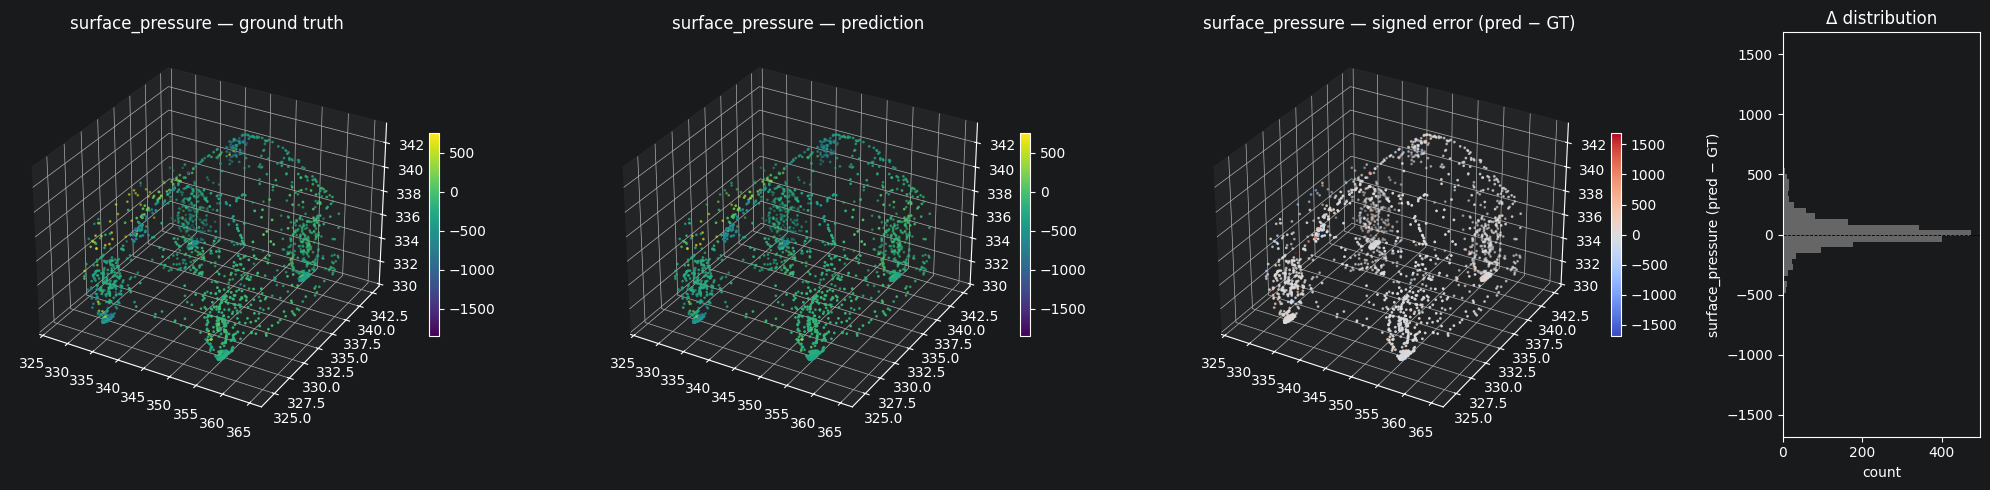

In [30]:
field = "surface_pressure"  # change to e.g. "volume_velocity" to inspect the volume domain

# AeroCFD pipeline convention: GT for a target field lives under "<field>_target" in the collated batch
# (see AeroMultistagePipeline._build_collator_pipeline); the model's prediction dict uses the un-suffixed name.
pos = batch["surface_anchor_position"][0].cpu()
gt_phys = norms[field].inverse(batch[f"{field}_target"][0].cpu())
pred_phys = norms[field].inverse(pred[field][0].cpu())

plot_prediction(positions=pos, gt=gt_phys, pred=pred_phys, field=field)

## Next steps

- **Reproducible eval** — `python -m showcase.cli evaluate --dataset-root <...> --output-path <...> --run-id <...>` runs the full pipeline (metrics, predictions, VTK export, force computation).
- **ParaView export** — `recipes/aero_cfd/showcase/utils/vtk_export.py:export_pointcloud_to_vtk` writes a VTP point cloud from the prediction dict.
- **A different recipe** — `Run` is recipe-agnostic. For models other than AB-UPT, swap `AB_UPT_FORWARD_KEYS` for the recipe's own `forward_properties_map` entry; everything else stays the same.